## Imports and plotting parameters

In [41]:
from src import *

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'text.latex.preamble':r'\usepackage{amsmath}',
    'text.latex.preamble':r'\usepackage{fourier}'
})
w, l, l_log = 1.25, 10, 6
pad, lpad, shrink = 0.12, 5, 0.8

## Simulation outputs and normalizations 

In [45]:
# Reading the .ini file
conf = inifix.load("idefix.ini")
n_average = int(conf["TimeIntegrator"]["tstop"] / conf["Output"]["analysis"]) + 1
n_vtk = int(conf["TimeIntegrator"]["tstop"] / conf["Output"]["vtk"]) + 1
r_min = conf["Grid"]["X1-grid"][1]
r_max = conf["Grid"]["X1-grid"][-1]
n_r = conf["Grid"]["X1-grid"][2]
epsilon = conf["Setup"]["epsilon"]
alpha = conf["Setup"]["alpha"]
densityFloor = conf["Setup"]["densityFloor"]
gravity = conf["Setup"]["gravity"]
beta_0 = conf["Setup"]["tilt"] * np.pi/180
spin = conf["Setup"]["spin"]

# Reading the analysis files
t, M_tot = READ_BOX_AVERAGE()
r, Sigma, rho_mean, L, beta, gamma, rho_Vr, rho_Vperp = READ_RADIAL_AVERAGE(n_average, n_r, beta_0)

# Time
r_norm = r_min
grad_Phi = 0
if gravity == "Kepler":
    grad_Phi = 1/r_norm**2
elif gravity == "Einstein":
    grad_Phi = 1/r_norm**2 + 6/r_norm**3
omega_orbit = np.sqrt(r_norm * grad_Phi) / (2*np.pi*r_norm)
n_orbit = 20
t *= omega_orbit
T, R = np.meshgrid(t, r, indexing="ij")

# Warp profile
L_unit = np.zeros_like(L)
L_unit[:,:,0] = L[:,:,0] / np.sqrt(L[:,:,0]**2 + L[:,:,1]**2 + L[:,:,2]**2)
L_unit[:,:,1] = L[:,:,1] / np.sqrt(L[:,:,0]**2 + L[:,:,1]**2 + L[:,:,2]**2)
L_unit[:,:,2] = L[:,:,2] / np.sqrt(L[:,:,0]**2 + L[:,:,1]**2 + L[:,:,2]**2)
psi = R * np.sqrt(np.gradient(L_unit[:,:,0], r, axis=1)**2 + np.gradient(L_unit[:,:,1], r, axis=1)**2 + np.gradient(L_unit[:,:,2], r, axis=1)**2)

# Nodal and precession frequencies
# To do

# Accretion rate
M_dot = np.mean(2*np.pi*R * Sigma * (-rho_Vr / rho_mean), axis=0)
omega_K = KEPLER(r)
v_K = r * omega_K
c_s = epsilon * v_K
M_dot_visc = 2*np.pi*r * Sigma[0,:] * (alpha*epsilon*c_s)
omega_perp = np.mean(rho_Vperp / (R * rho_mean), axis=0)
kappa2_perp = 4*omega_perp**2 + 2*r*omega_perp * np.gradient(omega_perp, r)

## Tilt and precession angles

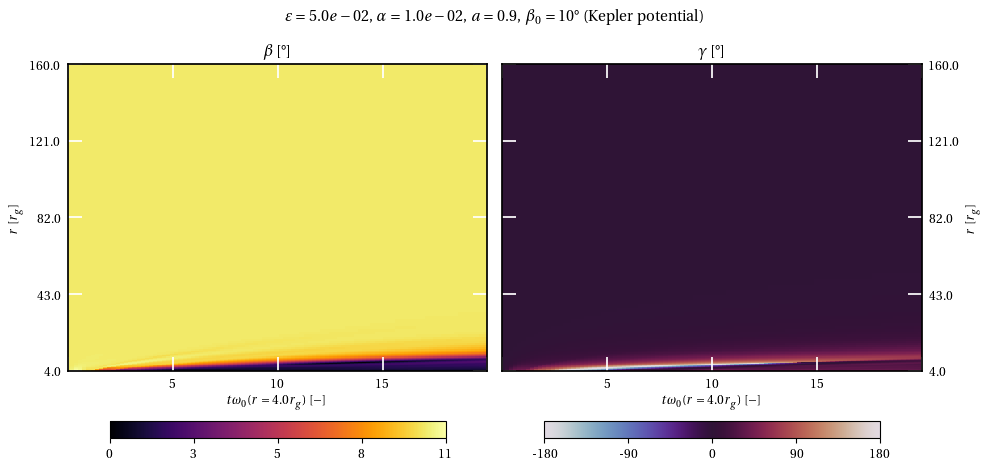

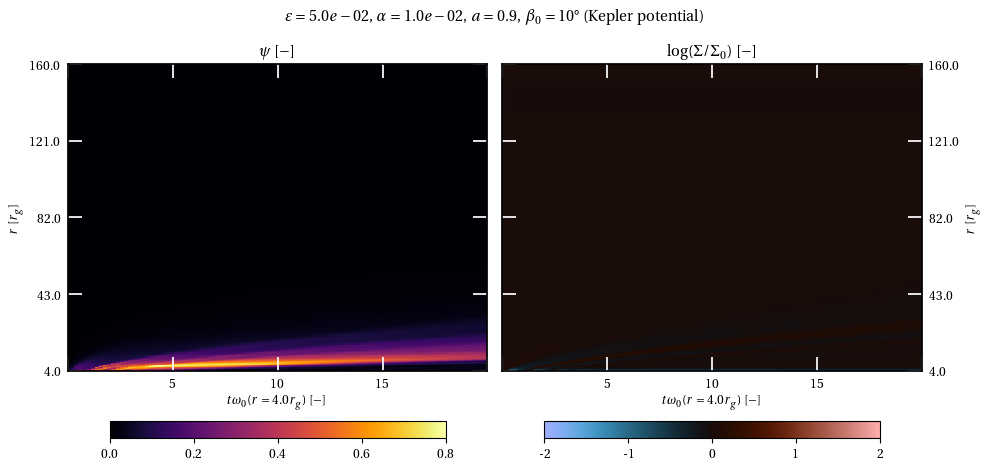

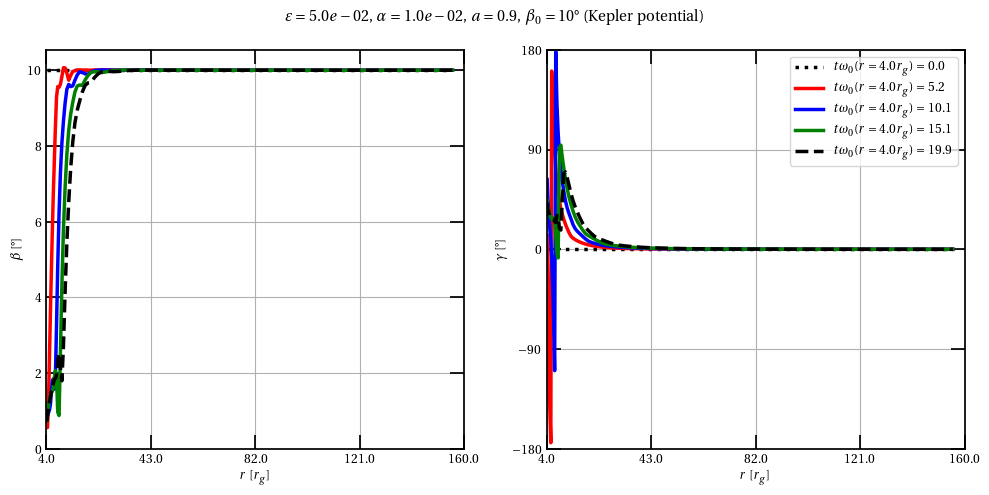

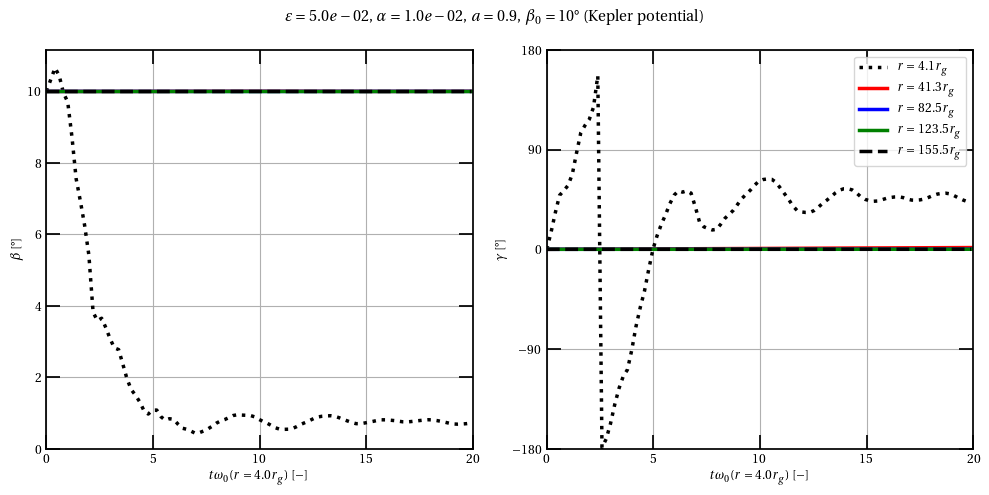

In [48]:
# angles vs. radius & time
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.set_title(r"$\beta$ $[$°$]$")
buff = np.max(np.abs(beta))
ticks = np.linspace(0, buff, 5)
pc0 = ax.pcolormesh(T, R, beta, cmap="inferno", vmin=0, vmax=buff)
formats = tkr.FormatStrFormatter('%.0f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(rf"$t\omega_0(r={r_norm}r_g)$ $[-]$")
ax.set_ylabel(r"$r$ $[r_g]$", labelpad=lpad)
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.1f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

ax = axs[1]
ax.set_title(r"$\gamma$ $[$°$]$")
buff = 180
ticks = np.linspace(-buff, buff, 5)
pc0 = ax.pcolormesh(T, R, gamma, cmap="twilight", vmin=-buff, vmax=buff)
formats = tkr.FormatStrFormatter('%.0f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(rf"$t\omega_0(r={r_norm}r_g)$ $[-]$")
ax.set_ylabel(r"$r$ $[r_g]$", labelpad=lpad)
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.1f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/angles.png", bbox_inches='tight', dpi=500)
plt.show()
plt.close()

# disc breaking vs. radius & time
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.set_title(r"$\psi$ $[-]$")
buff = np.max(np.abs(psi))
ticks = np.linspace(0, buff, 5)
pc0 = ax.pcolormesh(T, R, psi, cmap="inferno", vmin=0, vmax=buff)
formats = tkr.FormatStrFormatter('%.1f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(rf"$t\omega_0(r={r_norm}r_g)$ $[-]$")
ax.set_ylabel(r"$r$ $[r_g]$", labelpad=lpad)
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.1f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

ax = axs[1]
ax.set_title(r"$\log(\Sigma/\Sigma_0)$ $[-]$")
ticks = np.linspace(-2, 2, 5)
Sigma_PLOT = np.zeros_like(Sigma)
for n in range(t.size):
    Sigma_PLOT[n,:] = Sigma[n,:] / Sigma[0,:]
pc0 = ax.pcolormesh(T, R, np.log10(Sigma_PLOT), cmap="berlin", vmin=-2, vmax=2)
formats = tkr.FormatStrFormatter('%.0f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(rf"$t\omega_0(r={r_norm}r_g)$ $[-]$")
ax.set_ylabel(r"$r$ $[r_g]$", labelpad=lpad)
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.1f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/anglesBreaking.png", bbox_inches='tight', dpi=500)
plt.show()
plt.close()

# angles vs. radius
n0 = 0
n1 = np.where(t >= n_orbit/4)[0][0]
n2 = np.where(t >= 2*n_orbit/4)[0][0]
n3 = np.where(t >= 3*n_orbit/4)[0][0]
n4 = -1

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.plot(r, beta[n0,:], color="black", linestyle="dotted", linewidth=2.5)
ax.plot(r, beta[n1,:], color="red", linewidth=2.5)
ax.plot(r, beta[n2,:], color="blue", linewidth=2.5)
ax.plot(r, beta[n3,:], color="green", linewidth=2.5)
ax.plot(r, beta[n4,:], color="black", linestyle="dashed", linewidth=2.5)
ax.set_xlim((r_min, r_max))
xplot = np.linspace(r_min, r_max, 5)
xl = [f"{i:.1f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$r$ $[r_g]$")
ax.set_ylabel(r"$\beta$ $[$°$]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

ax = axs[1]
ax.plot(r, gamma[n0,:], color="black", linestyle="dotted", label=rf"$t\omega_0(r = {r_norm}r_g) =$ {t[n0]:.1f}", linewidth=2.5)
ax.plot(r, gamma[n1,:], color="red", label=rf"$t\omega_0(r = {r_norm}r_g) =$ {t[n1]:.1f}", linewidth=2.5)
ax.plot(r, gamma[n2,:], color="blue", label=rf"$t\omega_0(r = {r_norm}r_g) =$ {t[n2]:.1f}", linewidth=2.5)
ax.plot(r, gamma[n3,:], color="green", label=rf"$t\omega_0(r = {r_norm}r_g) =$ {t[n3]:.1f}", linewidth=2.5)
ax.plot(r, gamma[n4,:], color="black", linestyle="dashed", label=rf"$t\omega_0(r = {r_norm}r_g) =$ {t[n4]:.1f}", linewidth=2.5)
ax.set_xlim((r_min, r_max))
ax.set_ylim((-180,180))
yplot = np.linspace(-180, 180, 5)
ax.set_yticks(yplot)
xplot = np.linspace(r_min, r_max, 5)
xl = [f"{i:.1f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_xlabel(r"$r$ $[r_g]$")
ax.set_ylabel(r"$\gamma$ $[$°$]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/anglesVSradius.pdf", bbox_inches='tight')
plt.show()
plt.close()

# angles vs. time
n0 = 0
n1 = np.where(r >= r_max/4)[0][0]
n2 = np.where(r >= 2*r_max/4)[0][0]
n3 = np.where(r >= 3*r_max/4)[0][0]
n4 = -1

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.plot(t, beta[:,n0], color="black", linestyle="dotted", linewidth=2.5)
ax.plot(t, beta[:,n1], color="red", linewidth=2.5)
ax.plot(t, beta[:,n2], color="blue", linewidth=2.5)
ax.plot(t, beta[:,n3], color="green", linewidth=2.5)
ax.plot(t, beta[:,n4], color="black", linestyle="dashed", linewidth=2.5)
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_ylim(bottom=0)
ax.set_xlabel(rf"$t\omega_0(r={r_norm}r_g)$ $[-]$")
ax.set_ylabel(r"$\beta$ $[$°$]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

ax = axs[1]
ax.plot(t, gamma[:,n0], color="black", linestyle="dotted", label=rf"$r =$ {r[n0]:.1f}$r_g$", linewidth=2.5)
ax.plot(t, gamma[:,n1], color="red", label=rf"$r =$ {r[n1]:.1f}$r_g$", linewidth=2.5)
ax.plot(t, gamma[:,n2], color="blue", label=rf"$r =$ {r[n2]:.1f}$r_g$", linewidth=2.5)
ax.plot(t, gamma[:,n3], color="green", label=rf"$r =$ {r[n3]:.1f}$r_g$", linewidth=2.5)
ax.plot(t, gamma[:,n4], color="black", linestyle="dashed", label=rf"$r =$ {r[n4]:.1f}$r_g$", linewidth=2.5)
ax.set_xlim((0, n_orbit))
ax.set_ylim((-180,180))
yplot = np.linspace(-180, 180, 5)
ax.set_yticks(yplot)
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_xlabel(rf"$t\omega_0(r={r_norm}r_g)$ $[-]$")
ax.set_ylabel(r"$\gamma$ $[$°$]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/anglesVStime.pdf", bbox_inches='tight')
plt.show()
plt.close()

## Dynamics

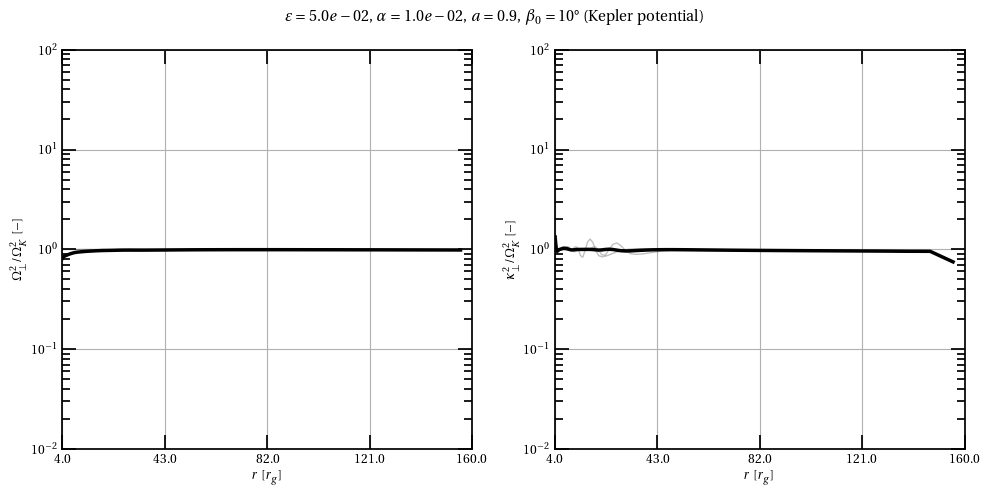

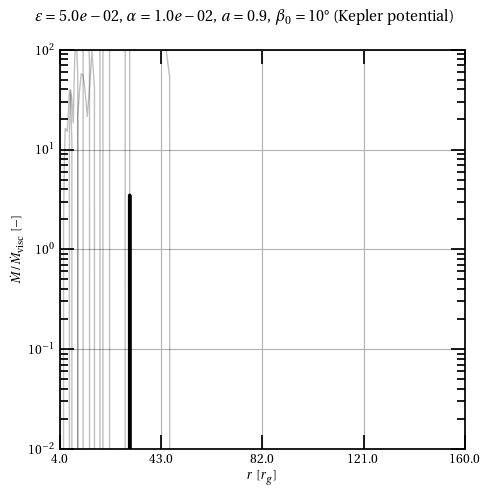

In [44]:
# rotation curve
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.plot(r, omega_perp**2/omega_K**2, color="black", linewidth=2.5)
for i in range(t.size):
    if i%50 == 0:
        omega_perp_i = rho_Vperp[i,:] / (r * rho_mean[i,:])
        ax.plot(r, omega_perp_i**2/omega_K**2, color="black", alpha=0.25, linewidth=1)
ax.set_xlim((r_min, r_max))
ax.set_xlabel(r"$r$ $[r_g]$")
xplot = np.linspace(r_min, r_max, 5)
xl = [f"{i:.1f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_yscale("log")
ax.set_ylim((1e-2, 1e2))
ax.set_ylabel(r"$\Omega_\perp^2/\Omega_K^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

ax = axs[1]
ax.plot(r, kappa2_perp/omega_K**2, color="black", linewidth=2.5)
for i in range(t.size):
    if i%50 == 0:
        omega_perp_i = rho_Vperp[i,:] / (r * rho_mean[i,:])
        kappa2_perp_i = 4*omega_perp_i**2 + 2*r*omega_perp_i * np.gradient(omega_perp_i, r)
        ax.plot(r, kappa2_perp_i/omega_K**2, color="black", alpha=0.25, linewidth=1)
ax.set_xlim((r_min, r_max))
ax.set_xlabel(r"$r$ $[r_g]$")
ax.set_xticks(xplot, xl)
ax.set_yscale("log")
ax.set_ylim((1e-2, 1e2))
ax.set_ylabel(r"$\kappa_\perp^2/\Omega_K^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/rotation_curve.pdf", bbox_inches='tight')
plt.show()
plt.close()

# accretion rate
fig, axs = plt.subplots(1, figsize=(5, 5))

ax = axs
ax.plot(r, M_dot/M_dot_visc, color="black", linewidth=2.5)
for i in range(t.size):
    if i%50 == 0:
        M_dot_i = 2*np.pi*r * Sigma[i,:] * (-rho_Vr[i,:] / rho_mean[i,:])
        ax.plot(r, M_dot_i/M_dot_visc, color="black", alpha=0.25, linewidth=1)
ax.set_xlim((r_min, r_max))
ax.set_xlabel(r"$r$ $[r_g]$")
ax.set_xticks(xplot, xl)
ax.set_yscale("log")
ax.set_ylim((1e-2, 1e2))
ax.set_ylabel(r"$\dot{M} / \dot{M}_\mathrm{visc}$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/accretion_rate.pdf", bbox_inches='tight')
plt.show()
plt.close()